# Analysis of designs (without responses)

This notebook reproduces and extends notebook 2 from `definitive_screening_design` using pydoe for every design. It evaluates designs before any response is observed.

The comparison contains twelve designs, five candidate effect models, large correlation maps for every design, estimability and conditioning diagnostics, D/A efficiencies, prediction variance, and exact aliases for regular fractions.

For a practitioner, these diagnostics answer different questions: Can the proposed model be
estimated? Which effects can be separated? How much precision is obtained per run? A design
should be chosen against the model and decisions that matter, not by selecting the largest
efficiency number in isolation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import linalg
import pydoe

sns.set_theme(style="white")

## Design-analysis utilities

An explicit effects list is more precise than a generic polynomial degree: it can include two-factor interactions without quadratics, or quadratics without interactions. Here, `3-interactions` means products of three distinct factors.

In [2]:
def effect_matrix(design, effects=("intercept", "main")):
    """Construct a model matrix and readable term names."""
    A = np.asarray(design, dtype=float)
    n_runs, n_factors = A.shape
    columns, names = [], []

    if "intercept" in effects:
        columns.append(np.ones(n_runs))
        names.append("Intercept")
    if "main" not in effects:
        raise ValueError("Main effects must be included")
    for i in range(n_factors):
        columns.append(A[:, i])
        names.append(f"X{i + 1}")
    if "2-interactions" in effects:
        for i in range(n_factors):
            for j in range(i + 1, n_factors):
                columns.append(A[:, i] * A[:, j])
                names.append(f"X{i + 1}:X{j + 1}")
    if "3-interactions" in effects:
        for i in range(n_factors):
            for j in range(i + 1, n_factors):
                for k in range(j + 1, n_factors):
                    columns.append(A[:, i] * A[:, j] * A[:, k])
                    names.append(f"X{i + 1}:X{j + 1}:X{k + 1}")
    if "quadratic" in effects:
        for i in range(n_factors):
            columns.append(A[:, i] ** 2)
            names.append(f"X{i + 1}²")
    return np.column_stack(columns), names


def design_report(design, effects=("intercept", "main")):
    """Return response-independent model diagnostics."""
    X, _ = effect_matrix(design, effects)
    rank = np.linalg.matrix_rank(X)
    estimable = rank == X.shape[1]
    return {
        "runs": X.shape[0],
        "parameters": X.shape[1],
        "rank": rank,
        "estimable": estimable,
        "condition number": np.linalg.cond(X) if estimable else np.inf,
        "D-efficiency (%)": pydoe.d_efficiency(X) if estimable else 0.0,
        "A-efficiency (%)": pydoe.a_efficiency(X) if estimable else 0.0,
    }


def prediction_variance(design, points, effects=("intercept", "main")):
    """Evaluate x' (X'X)^+ x at each requested point."""
    X, _ = effect_matrix(design, effects)
    Xp, _ = effect_matrix(points, effects)
    information_inverse = linalg.pinvh(X.T @ X)
    return np.einsum("ij,jk,ik->i", Xp, information_inverse, Xp)


def safe_column_correlations(X):
    """Compute Pearson correlations, leaving constant terms as NaN."""
    X = np.asarray(X, dtype=float)
    centered = X - X.mean(axis=0)
    norms = np.linalg.norm(centered, axis=0)
    column_scale = np.maximum(1.0, np.max(np.abs(X), axis=0))
    tolerance = np.finfo(float).eps * np.sqrt(X.shape[0]) * column_scale
    variable = norms > tolerance
    valid_pairs = np.outer(variable, variable)
    correlations = np.full((X.shape[1], X.shape[1]), np.nan)
    np.divide(
        centered.T @ centered,
        np.outer(norms, norms),
        out=correlations,
        where=valid_pairs,
    )
    correlations[valid_pairs] = np.clip(correlations[valid_pairs], -1.0, 1.0)
    return correlations


def plot_effect_correlations(
    design,
    effects,
    *,
    title,
    absolute=True,
    annotate=False,
    figsize=(12, 10),
):
    """Plot a large lower-triangular effect-correlation map."""
    X, names = effect_matrix(design, effects)
    if "intercept" in effects:
        X, names = X[:, 1:], names[1:]
    correlations = safe_column_correlations(X)
    if absolute:
        correlations = np.abs(correlations)
        vmin = 0
    else:
        vmin = -1

    mask = np.triu(np.ones_like(correlations, dtype=bool), k=1)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        correlations,
        mask=mask,
        cmap="RdYlGn_r",
        vmin=vmin,
        vmax=1,
        square=True,
        annot=annotate,
        xticklabels=names,
        yticklabels=names,
        linewidths=0.25,
        ax=ax,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return correlations

## The twelve designs

Every design has five columns and is coded to `[-1,+1]`.

The source notebook accidentally constructs both its Resolution-V and Resolution-III entries with `"a b c d abcd"`. Here the Resolution-III quarter fraction is correctly generated as `"a b c ab ac"`, giving eight runs and defining words of minimum length three.

In [3]:
k = 5

Aff2 = 2 * pydoe.fullfact([2] * k) - 1
Af2c = np.vstack([Aff2, np.zeros((3, k))])
AfrV = pydoe.fracfact("a b c d abcd")
AfrIII = pydoe.fracfact("a b c ab ac")
Aff3 = pydoe.fullfact([3] * k) - 1
Apb = pydoe.pbdesign(k)
Abb = pydoe.bbdesign(k)
Acc = pydoe.ccdesign(k, center=(4, 4), alpha="o", face="ccc")
Acc = Acc / np.max(np.abs(Acc))
Alh = 2 * pydoe.lhs(k, samples=25, criterion="centermaximin", iterations=1000, seed=42) - 1
A = pydoe.definitive_screening_design(k, min_13=True)
Ads1 = pydoe.definitive_screening_design(k, min_13=True, n_fake_factors=2)
Ads2 = pydoe.definitive_screening_design(k, min_13=True, n_fake_factors=4)

effects_tuple = (
    ["intercept", "main"],
    ["intercept", "main", "2-interactions"],
    ["intercept", "main", "quadratic"],
    ["intercept", "main", "2-interactions", "quadratic"],
    ["intercept", "main", "2-interactions", "3-interactions", "quadratic"],
)

does = {
    "2^k full-factorial": Aff2,
    "2^k ff w/center": Af2c,
    "2^(k-1) - V Resol.": AfrV,
    "2^(k-2) - III Resol.": AfrIII,
    "3^k full-factorial": Aff3,
    "Plackett-Burman": Apb,
    "Box-Behnken Surface": Abb,
    "Central-composite": Acc,
    "Latin-Hypercube MxMn": Alh,
    "Definitive Screening": A,
    "Def. Screen. - Augm1": Ads1,
    "Def. Screen. - Augm2": Ads2,
}

design_summary = pd.DataFrame([
    {
        "design": name,
        "runs": design.shape[0],
        "factors": design.shape[1],
        "minimum": design.min(),
        "maximum": design.max(),
        "distinct rows": len(np.unique(design, axis=0)),
    }
    for name, design in does.items()
]).set_index("design")
display(design_summary)

,runs,factors,minimum,maximum,distinct rows
design,,,,,
2^k full-factorial,32,5,-1.00,1.00,32
2^k ff w/center,35,5,-1.00,1.00,33
2^(k-1) - V Resol.,16,5,-1.00,1.00,16
2^(k-2) - III Resol.,8,5,-1.00,1.00,8
3^k full-factorial,243,5,-1.00,1.00,243
Plackett-Burman,8,5,-1.00,1.00,8
Box-Behnken Surface,46,5,-1.00,1.00,41
Central-composite,50,5,-1.00,1.00,43
Latin-Hypercube MxMn,25,5,-0.96,0.96,25


## Large-scale representation of every design matrix

Rows are experiments and columns are factor settings. Red and blue cells are high and low
settings; neutral cells are centers. The patterns reveal what the practitioner will actually run:
full factorials enumerate every combination, response-surface designs combine factorial,
center, and axial conditions, Latin hypercubes spread runs through the region, and DSDs use
mirrored foldover pairs plus center structure.

The displayed order is for diagnosis. Use a randomized `RunOrder` for execution when possible.

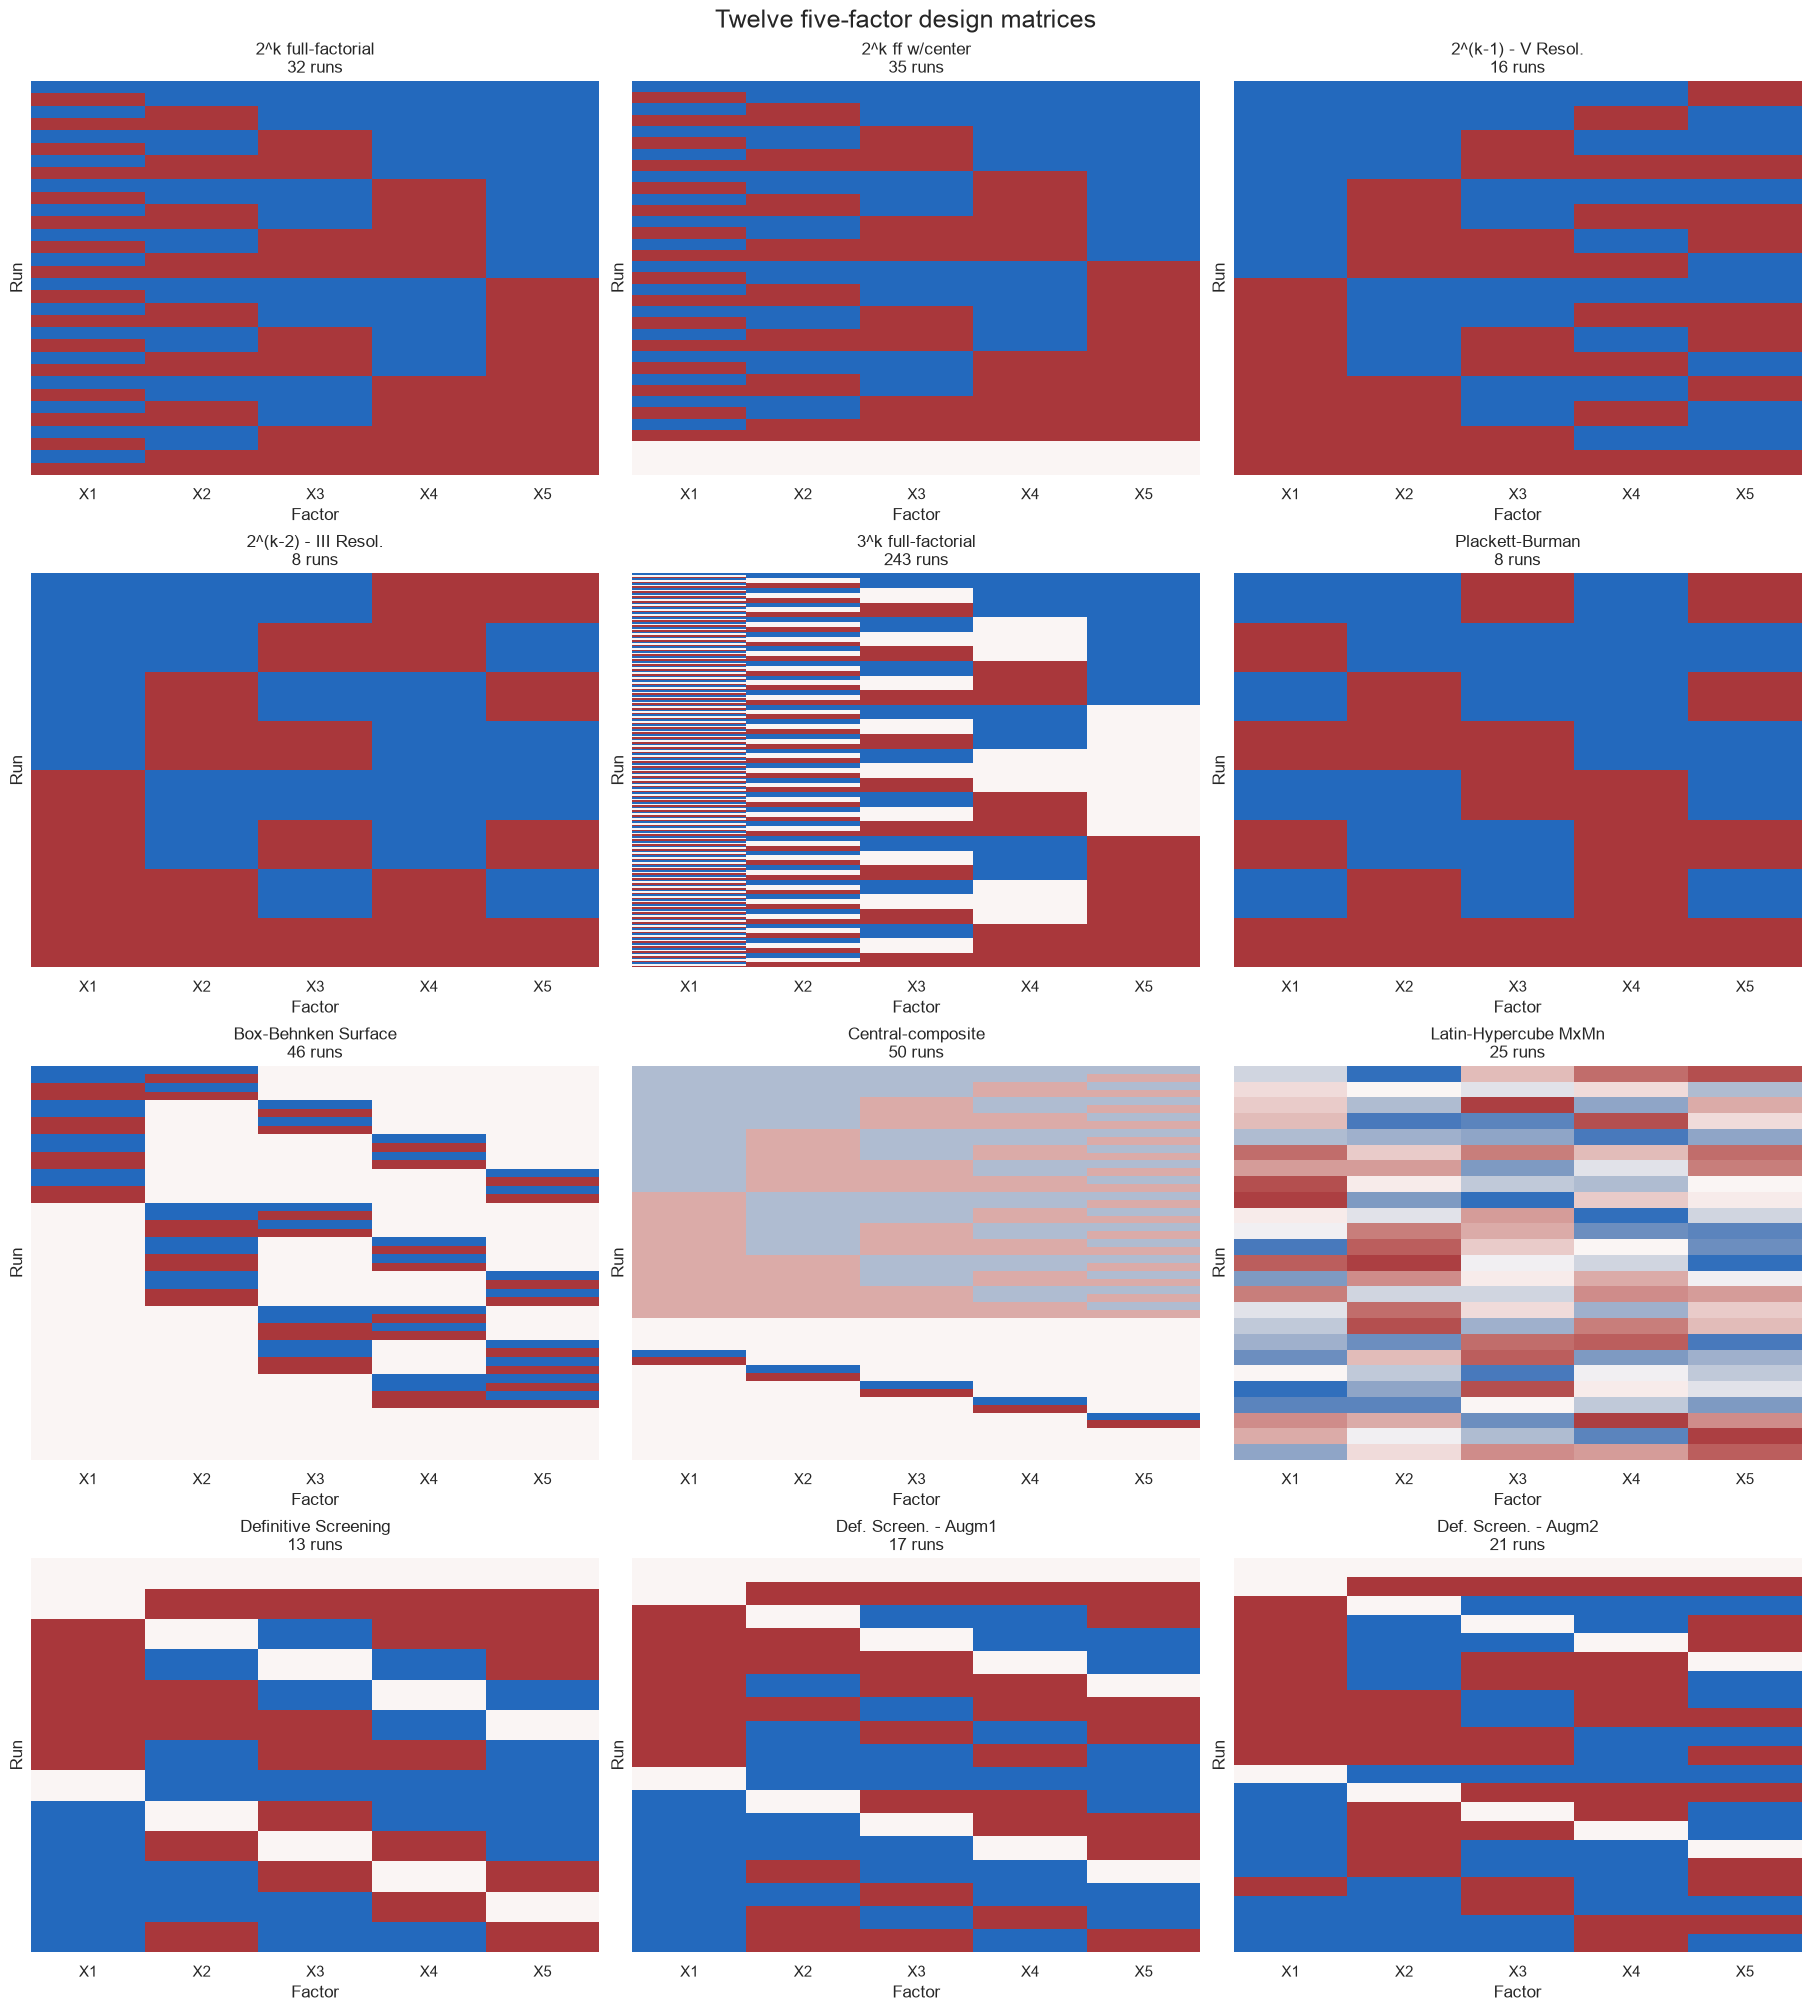

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20), constrained_layout=True)
for ax, (name, design) in zip(axes.flat, does.items()):
    sns.heatmap(
        design,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        cbar=False,
        xticklabels=[f"X{i}" for i in range(1, k + 1)],
        yticklabels=False,
        ax=ax,
    )
    ax.set_title(f"{name}\n{design.shape[0]} runs")
    ax.set(xlabel="Factor", ylabel="Run")
fig.suptitle("Twelve five-factor design matrices", fontsize=18)
plt.show()
plt.close(fig)

## Large effect-correlation map for every design

Each large map uses the richest model from `effects_tuple`: intercept, main effects, two- and three-factor interactions, and quadratics. The intercept is removed before correlation calculation. Blank cells arise when a term is constant—for example, squared columns in a two-level design—and therefore has undefined correlation.

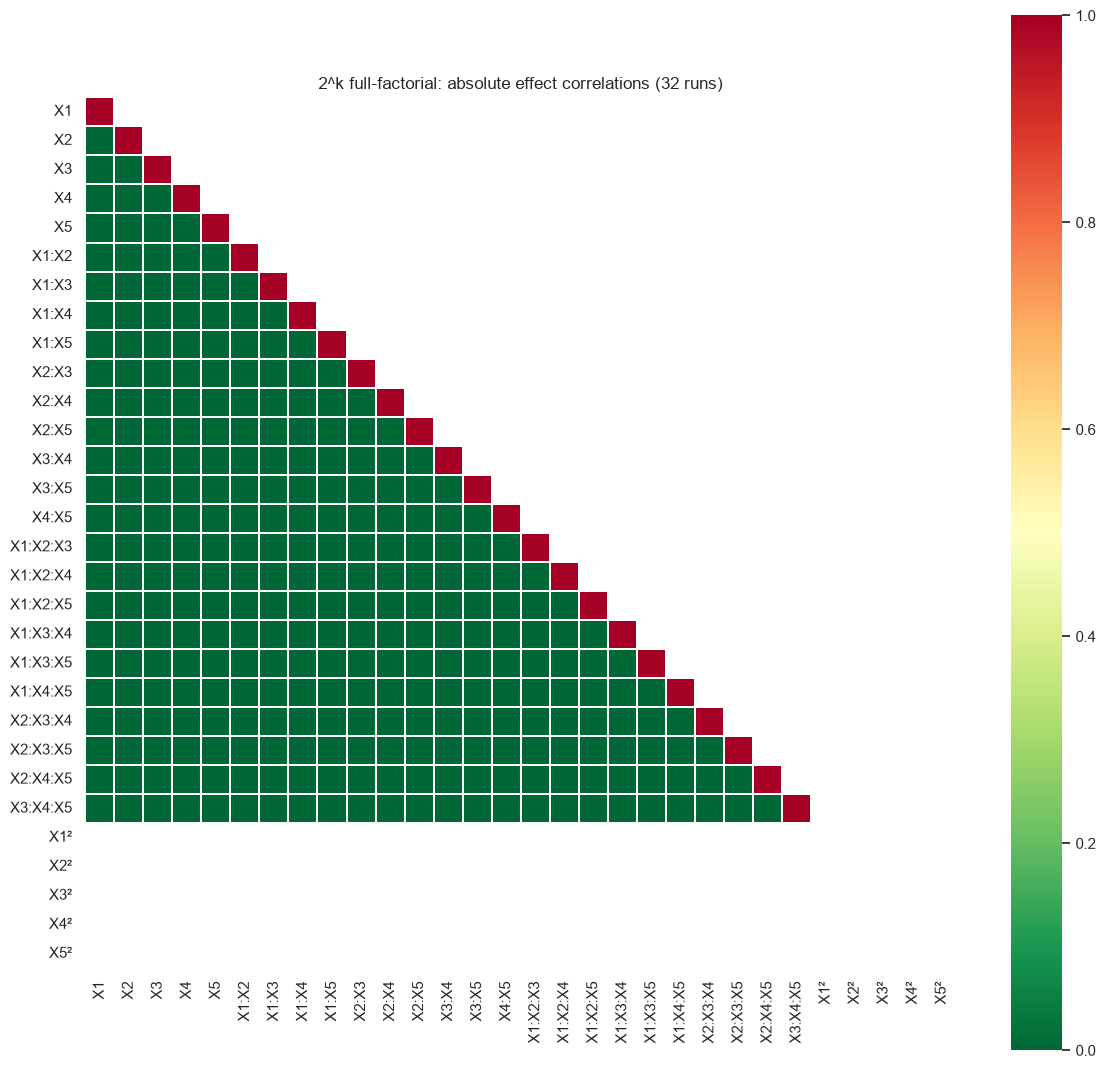

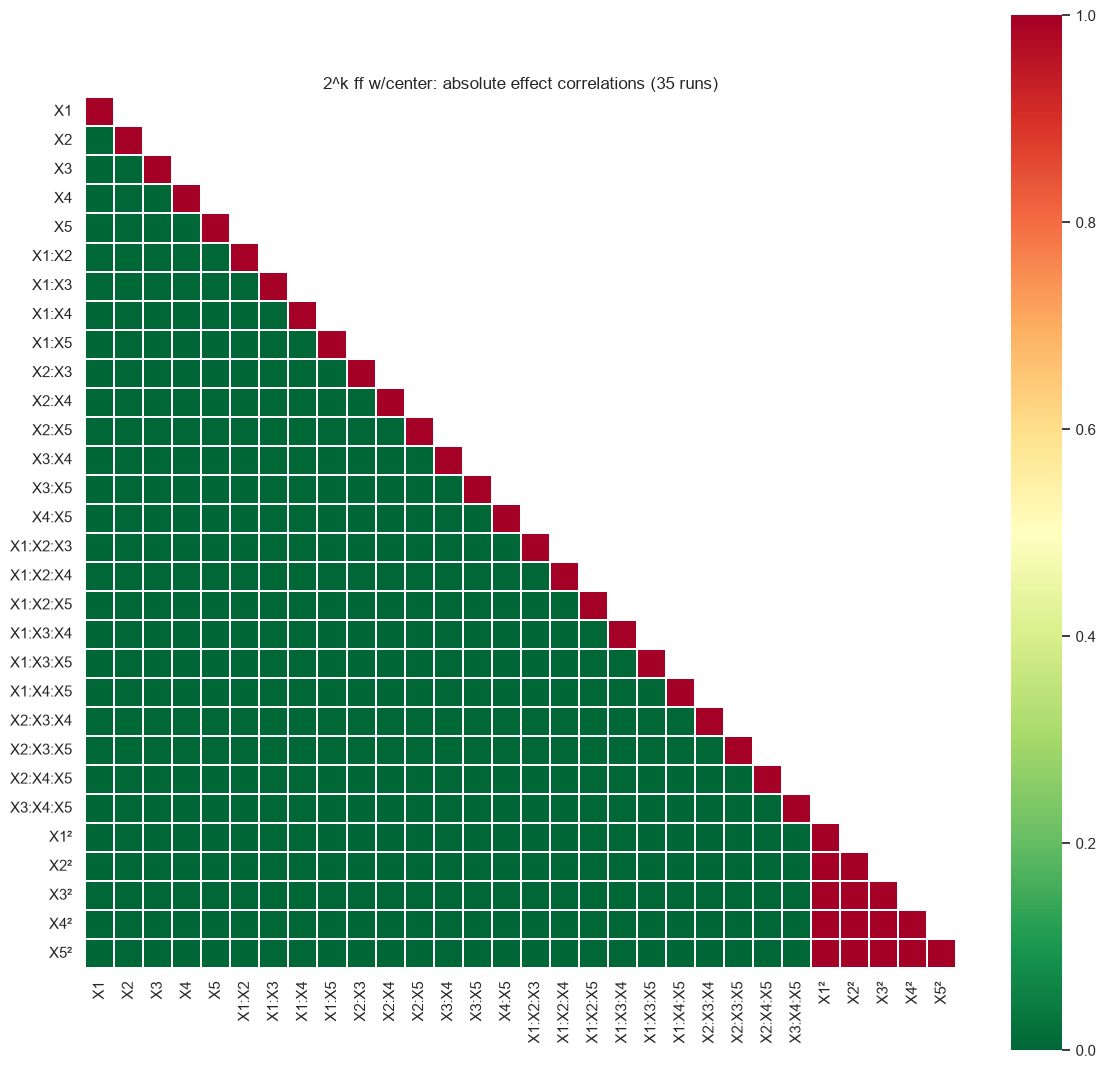

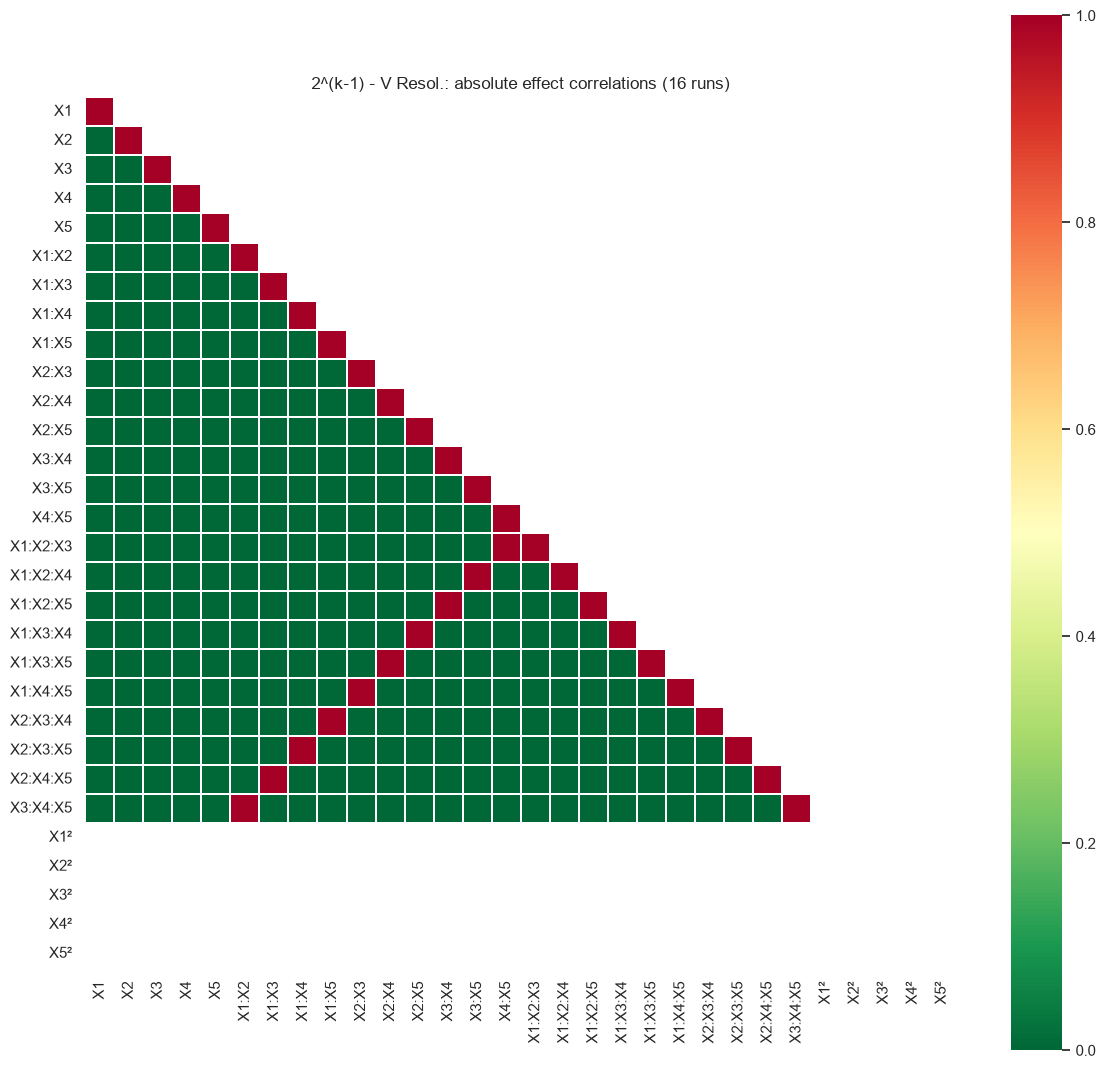

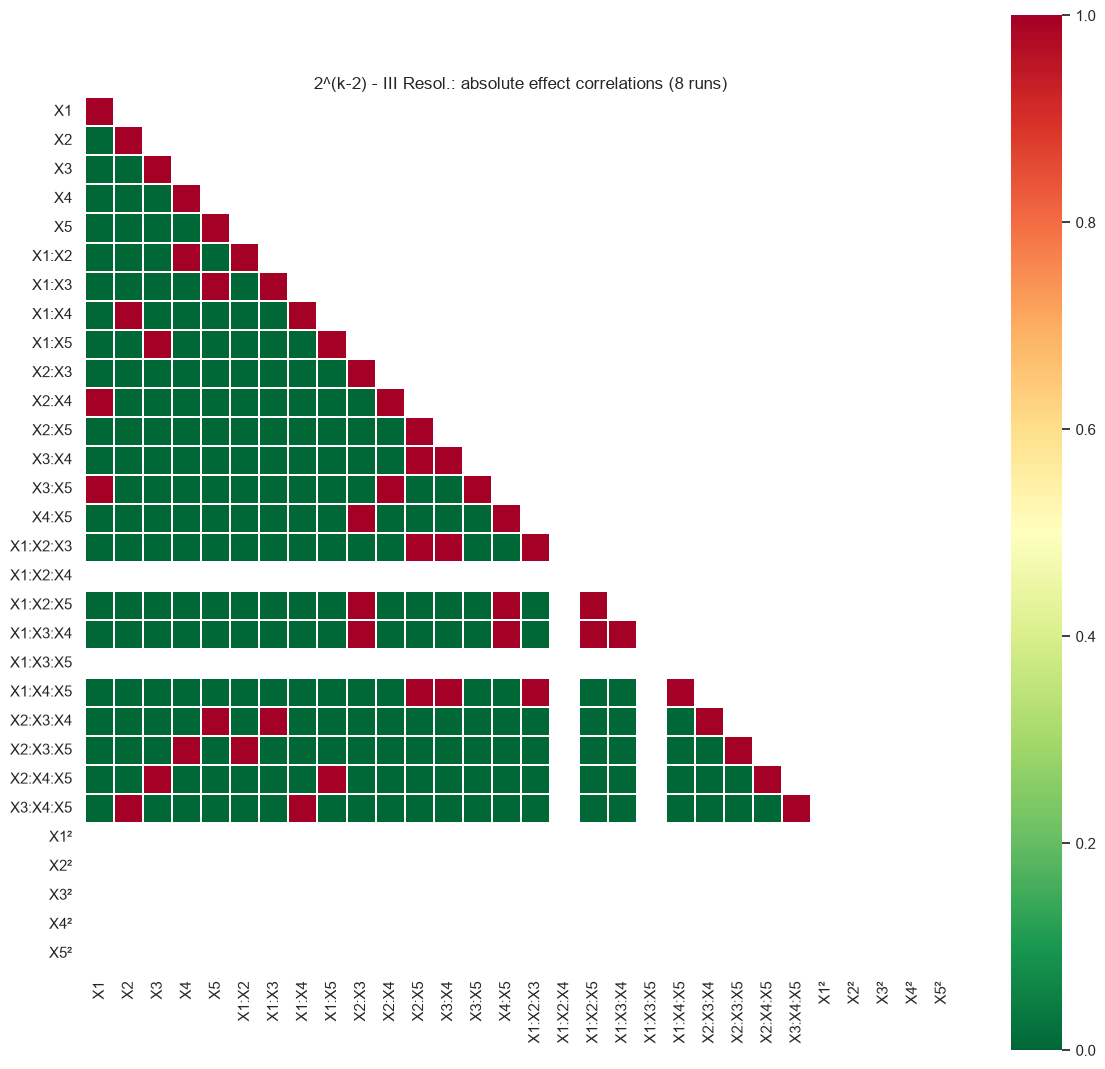

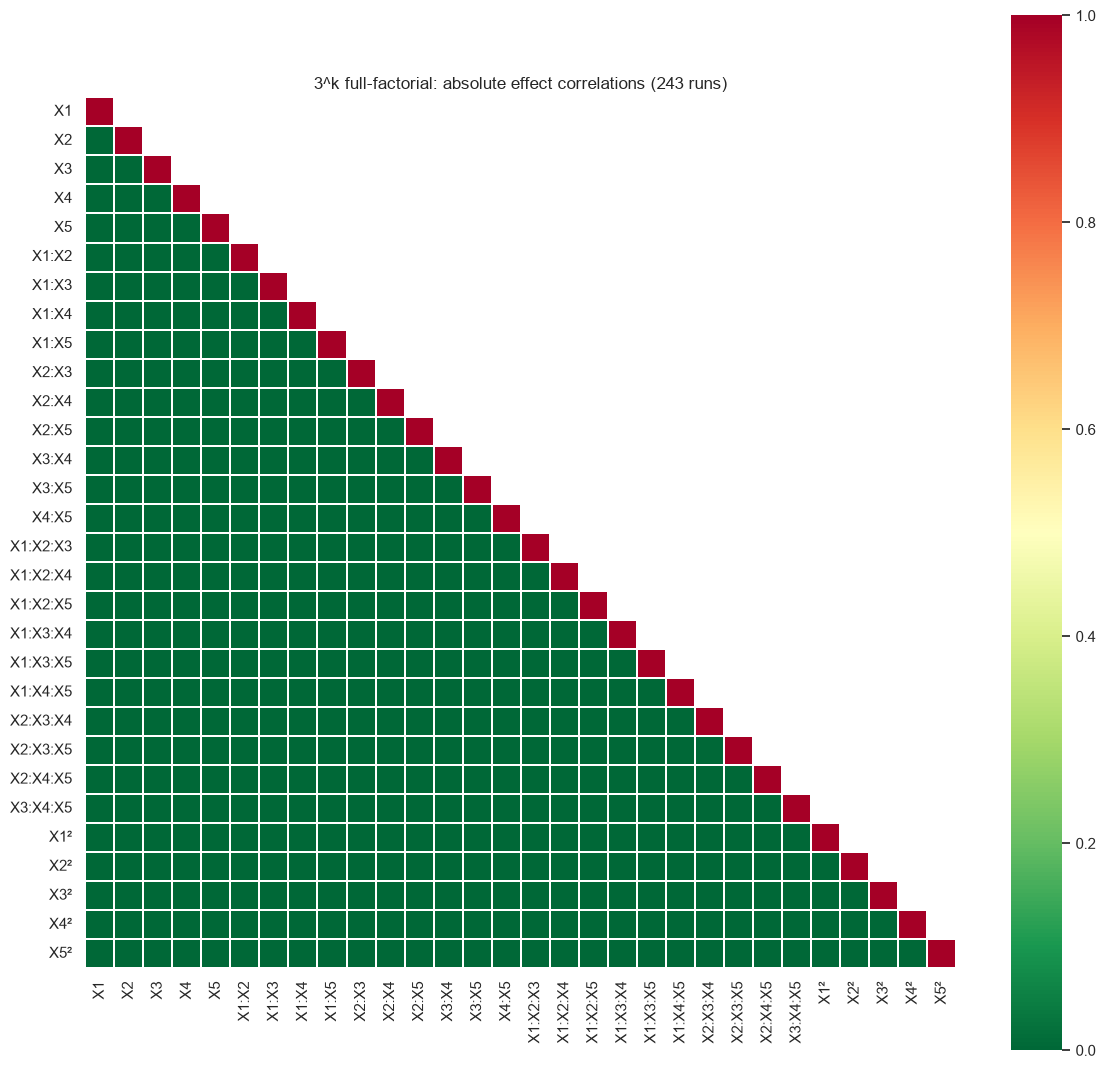

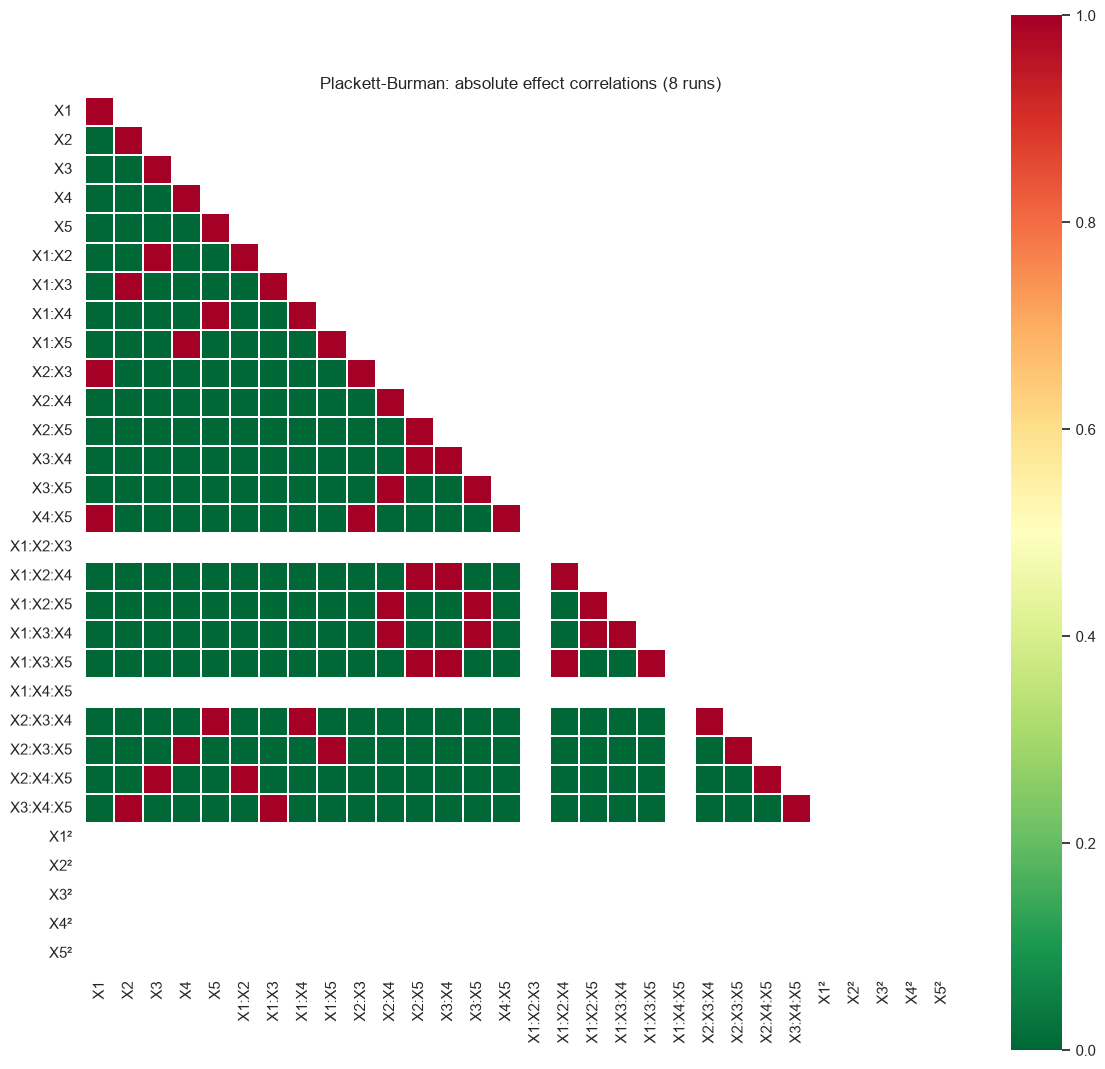

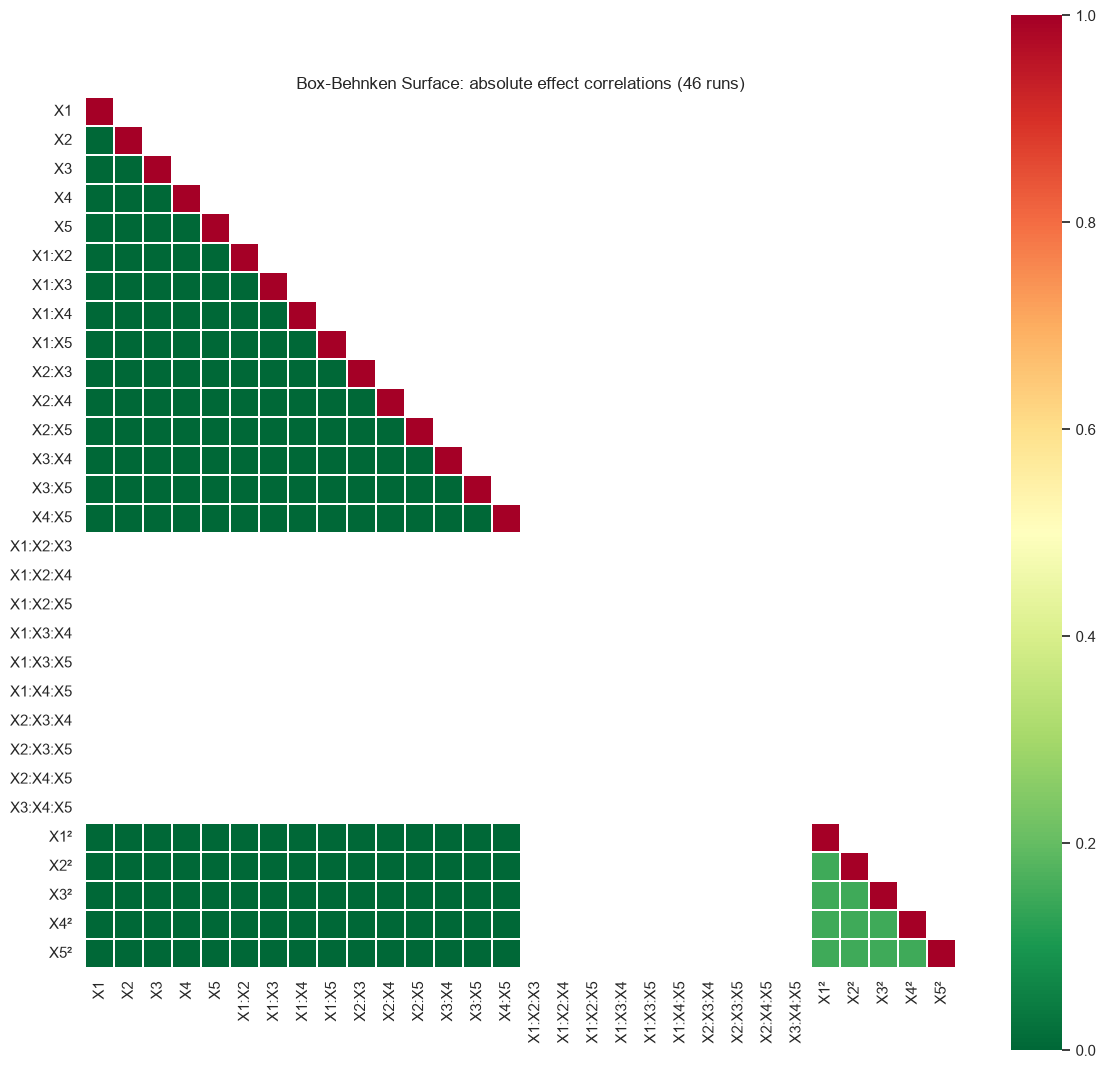

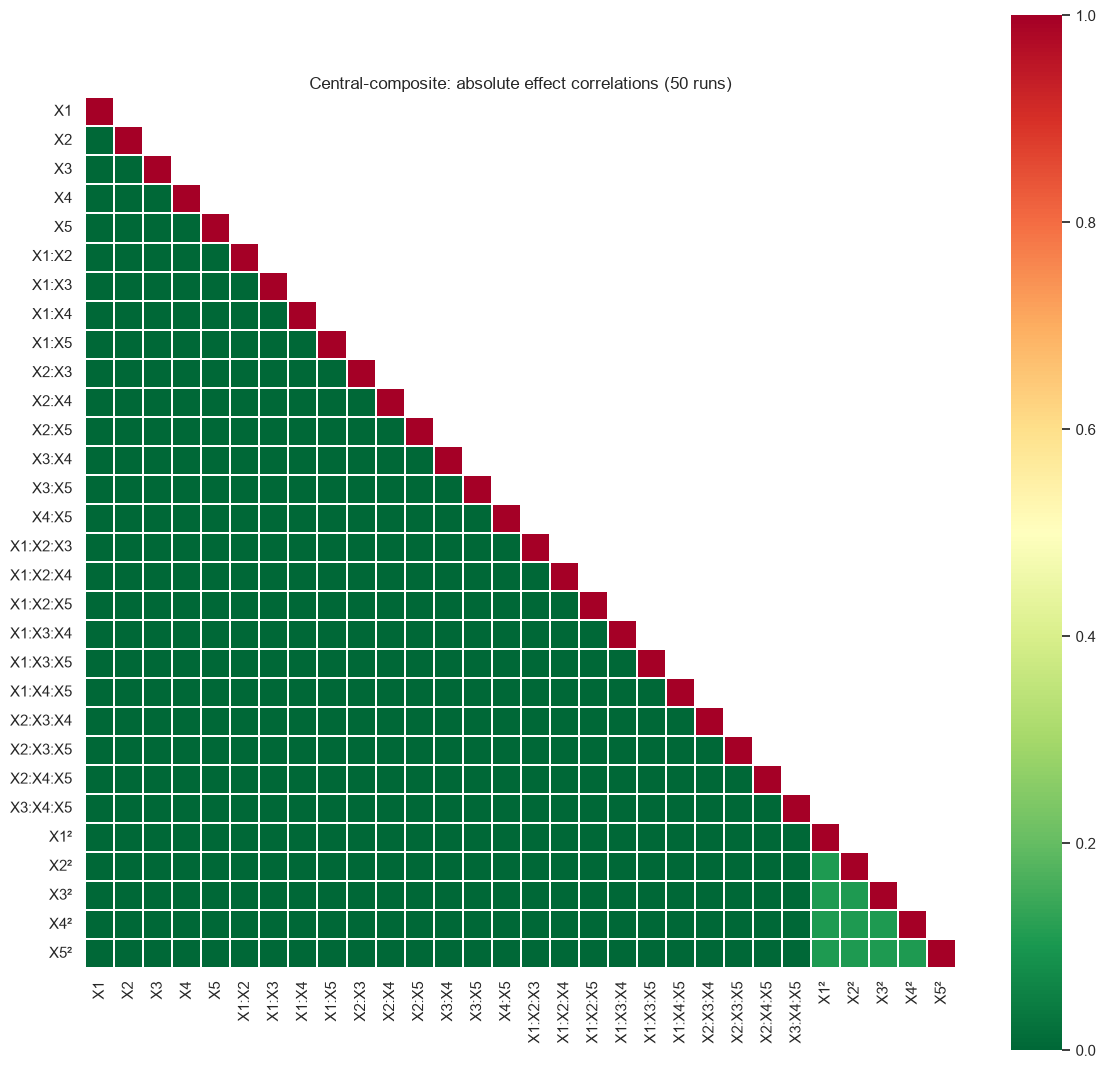

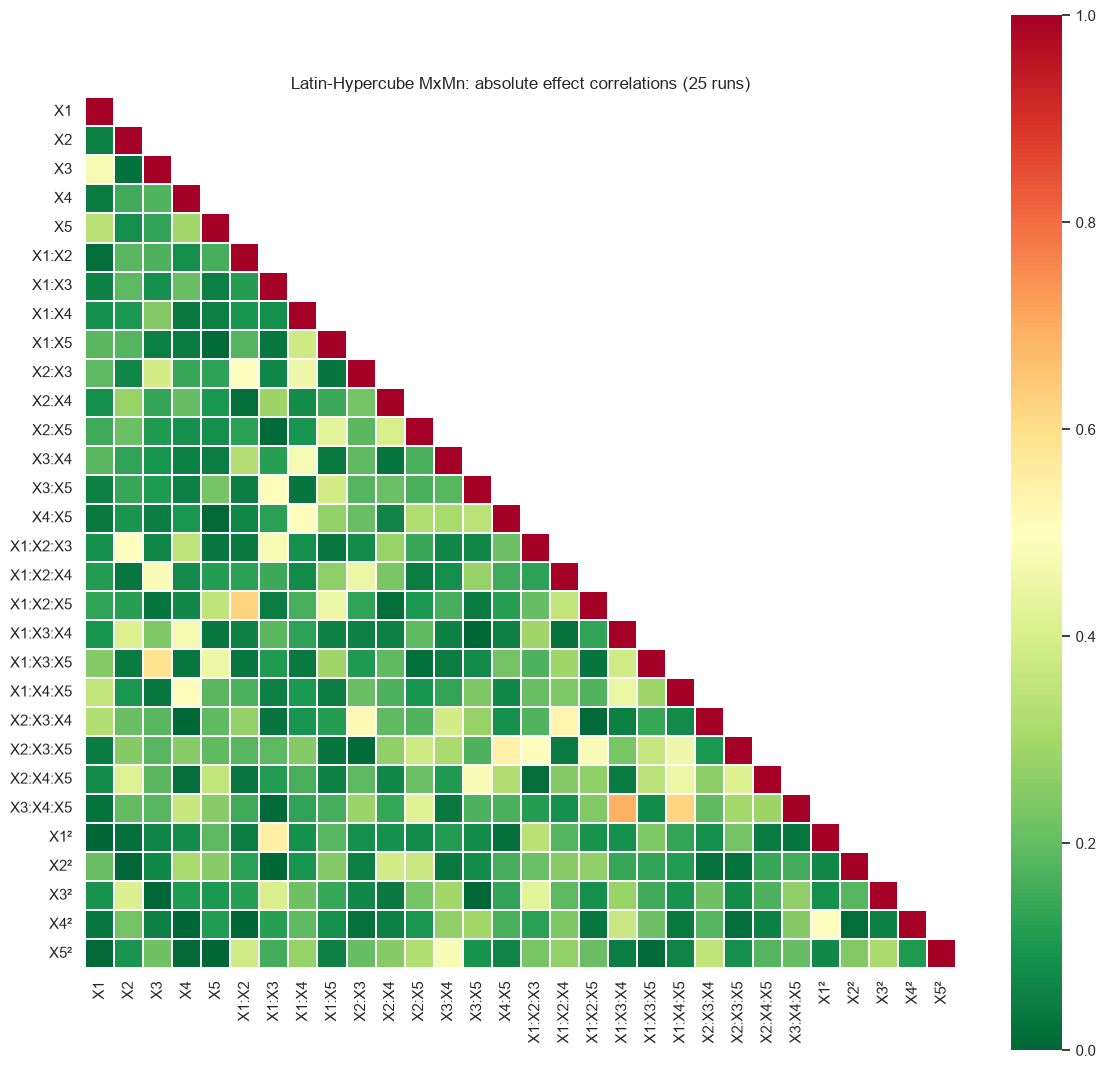

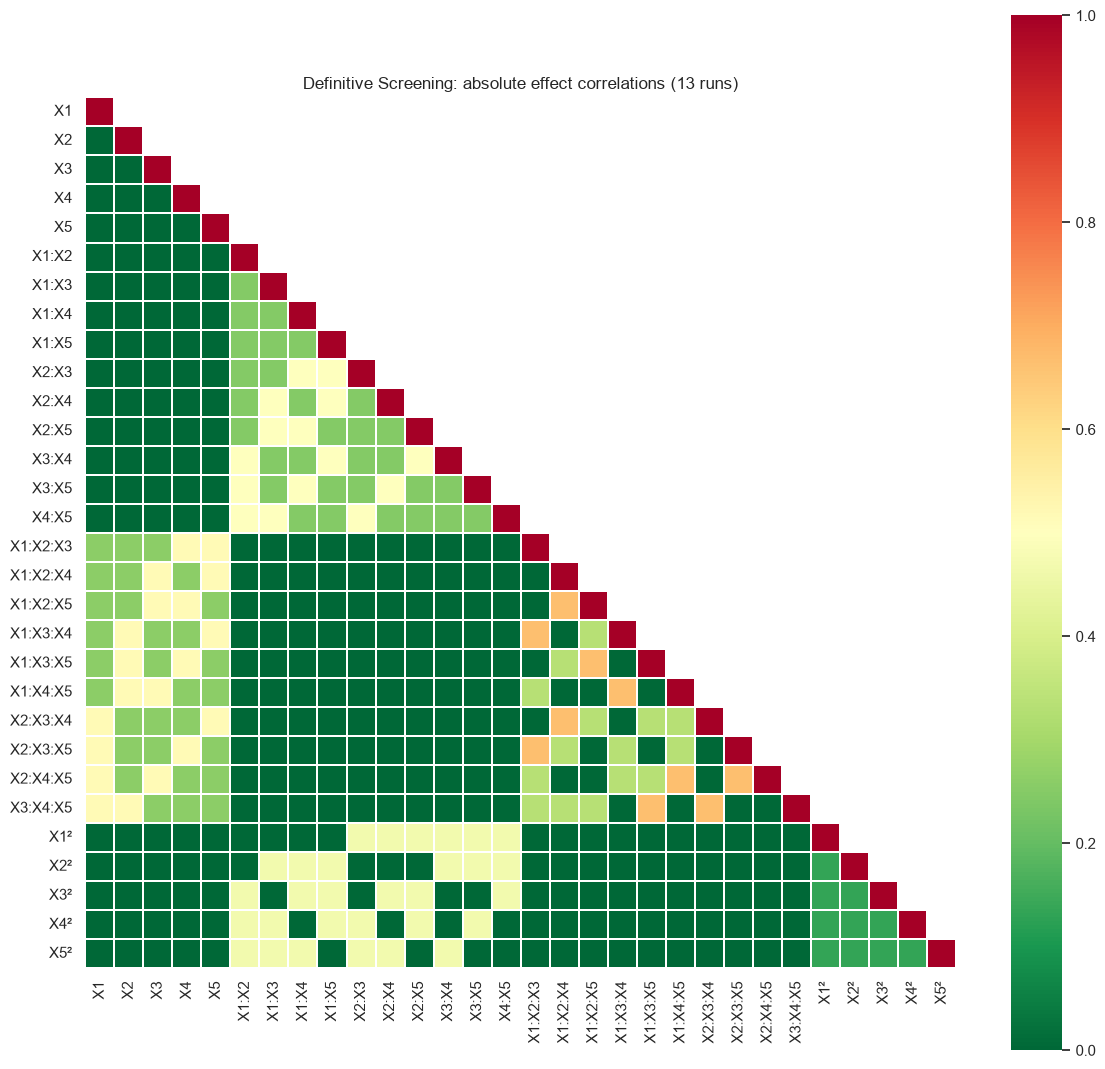

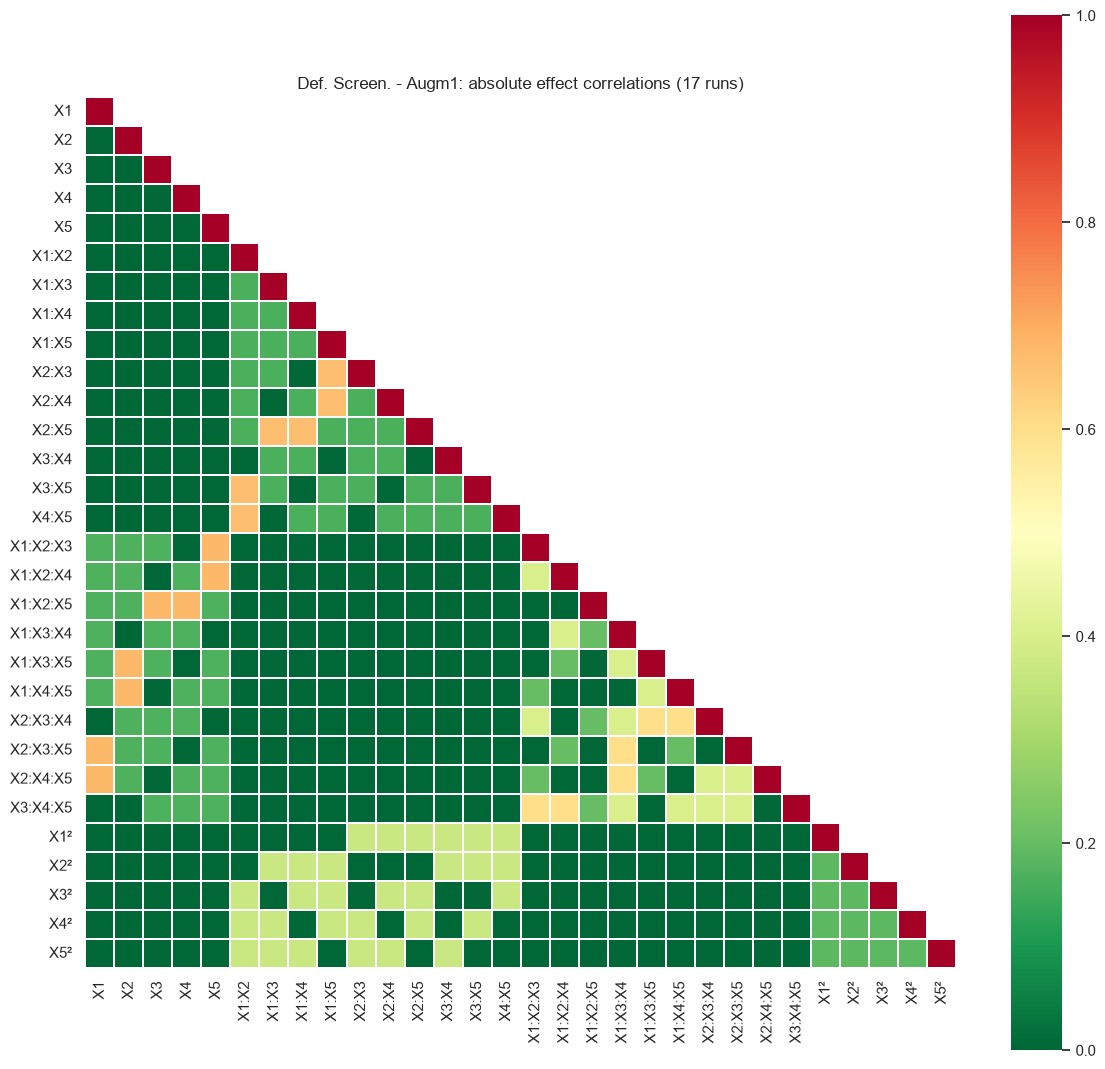

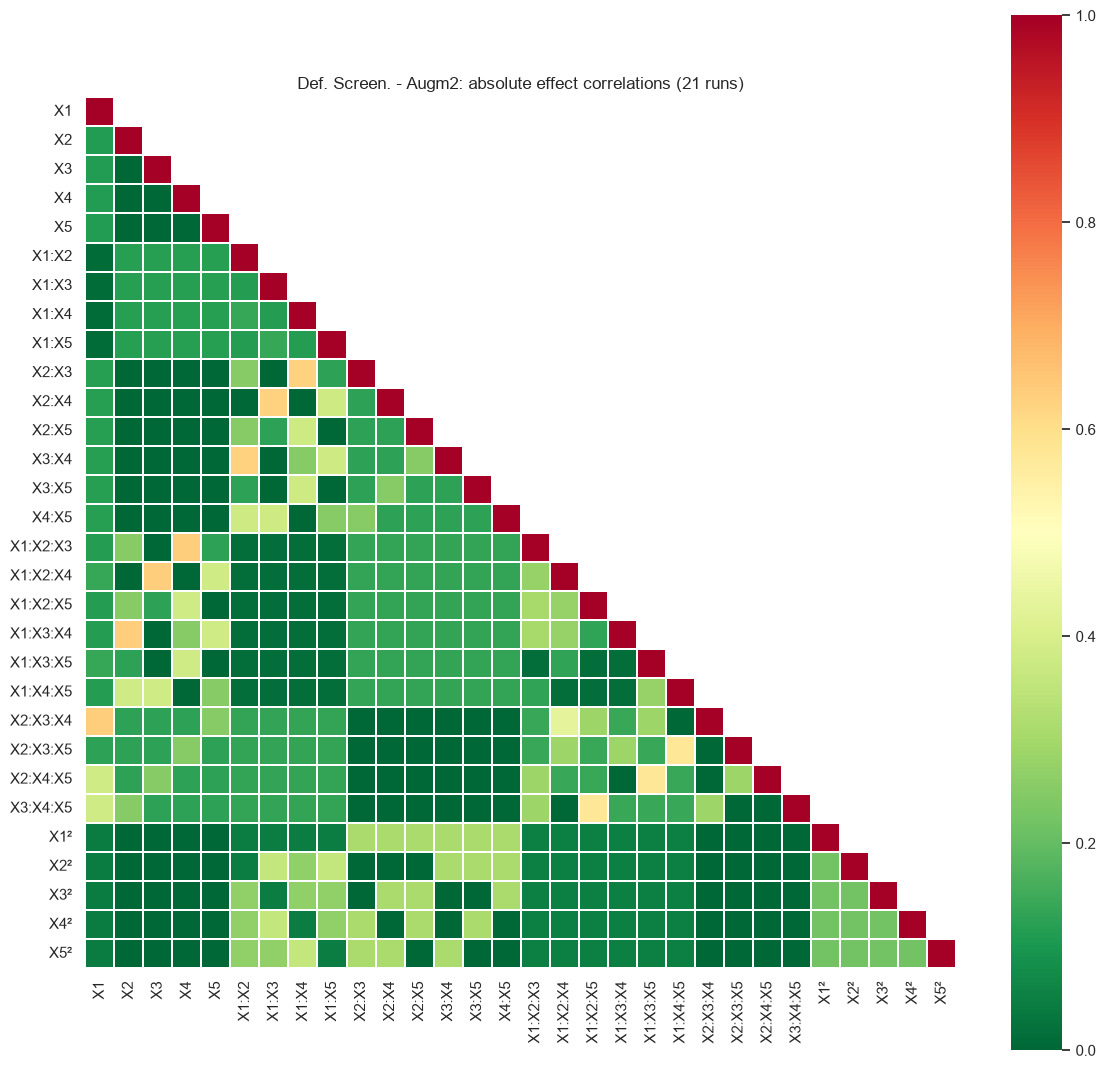

In [5]:
all_effects = effects_tuple[-1]
correlation_maps = {}
for name, design in does.items():
    correlation_maps[name] = plot_effect_correlations(
        design,
        all_effects,
        title=f"{name}: absolute effect correlations ({design.shape[0]} runs)",
        annotate=False,
        figsize=(12, 11),
    )

## Complete efficiency comparison for all five models

D- and A-efficiency are reported as zero when the requested model matrix is rank-deficient.
Rank and condition number prevent a superficially attractive value from hiding
non-estimability.

For practice:

- compare efficiencies only for the same coding, region, and candidate model;
- an efficient main-effects design may still be unable to estimate curvature or interactions;
- a rank-deficient full quadratic model means model selection or additional runs are required;
- augmentation should be planned before interpreting a sparse fitted model as confirmatory.

In [6]:
model_labels = [
    "intercept + main",
    "intercept + main + 2FI",
    "intercept + main + quadratic",
    "full quadratic",
    "main + 2FI + 3FI + quadratic",
]

records = []
for model_label, effects in zip(model_labels, effects_tuple):
    for design_name, design in does.items():
        records.append({
            "design": design_name,
            "model": model_label,
            **design_report(design, effects),
        })

comparison = pd.DataFrame(records)
display(comparison)

d_efficiency_table = comparison.pivot(index="design", columns="model", values="D-efficiency (%)")
a_efficiency_table = comparison.pivot(index="design", columns="model", values="A-efficiency (%)")
estimability_table = comparison.pivot(index="design", columns="model", values="estimable")

print("D-efficiency (%)")
display(d_efficiency_table.round(3))
print("A-efficiency (%)")
display(a_efficiency_table.round(3))
print("Estimable model?")
display(estimability_table)

,design,model,runs,parameters,rank,estimable,condition number,D-efficiency (%),A-efficiency (%)
0,2^k full-factorial,intercept + main,32,6,6,True,1.000000,100.000000,100.000000
1,2^k ff w/center,intercept + main,35,6,6,True,1.045825,92.804338,92.753623
2,2^(k-1) - V Resol.,intercept + main,16,6,6,True,1.000000,100.000000,100.000000
3,2^(k-2) - III Resol.,intercept + main,8,6,6,True,1.000000,100.000000,100.000000
4,3^k full-factorial,intercept + main,243,6,6,True,1.224745,71.327546,70.588235
5,Plackett-Burman,intercept + main,8,6,6,True,1.000000,100.000000,100.000000
6,Box-Behnken Surface,intercept + main,46,6,6,True,1.695582,41.476471,39.024390
7,Central-composite,intercept + main,50,6,6,True,2.645751,19.758394,16.666667
8,Latin-Hypercube MxMn,intercept + main,25,6,6,True,2.691449,36.528109,30.272359
9,Definitive Screening,intercept + main,13,6,6,True,1.140175,80.361347,80.000000


D-efficiency (%)


model,full quadratic,intercept + main,intercept + main + 2FI,intercept + main + quadratic,main + 2FI + 3FI + quadratic
design,,,,,
2^(k-1) - V Resol.,0.000,100.000,100.000,0.000,0.000
2^(k-2) - III Resol.,0.000,100.000,0.000,0.000,0.000
2^k ff w/center,0.000,92.804,91.942,0.000,0.000
2^k full-factorial,0.000,100.000,100.000,0.000,0.000
3^k full-factorial,43.136,71.328,53.071,41.980,38.214
Box-Behnken Surface,16.785,41.476,15.622,30.519,0.000
Central-composite,4.016,19.758,4.191,9.000,1.672
Def. Screen. - Augm1,0.000,85.061,0.000,37.146,0.000
Def. Screen. - Augm2,0.000,87.043,52.514,34.497,0.000


A-efficiency (%)


model,full quadratic,intercept + main,intercept + main + 2FI,intercept + main + quadratic,main + 2FI + 3FI + quadratic
design,,,,,
2^(k-1) - V Resol.,0.000,100.000,100.000,0.000,0.000
2^(k-2) - III Resol.,0.000,100.000,0.000,0.000,0.000
2^k ff w/center,0.000,92.754,91.921,0.000,0.000
2^k full-factorial,0.000,100.000,100.000,0.000,0.000
3^k full-factorial,33.071,70.588,51.613,26.829,31.877
Box-Behnken Surface,12.852,39.024,12.272,22.729,0.000
Central-composite,2.643,16.667,2.496,5.806,0.680
Def. Screen. - Augm1,0.000,84.848,0.000,18.894,0.000
Def. Screen. - Augm2,0.000,85.956,13.458,15.888,0.000


Estimable model?


model,full quadratic,intercept + main,intercept + main + 2FI,intercept + main + quadratic,main + 2FI + 3FI + quadratic
design,,,,,
2^(k-1) - V Resol.,False,True,True,False,False
2^(k-2) - III Resol.,False,True,False,False,False
2^k ff w/center,False,True,True,False,False
2^k full-factorial,False,True,True,False,False
3^k full-factorial,True,True,True,True,True
Box-Behnken Surface,True,True,True,True,False
Central-composite,True,True,True,True,True
Def. Screen. - Augm1,False,True,False,True,False
Def. Screen. - Augm2,False,True,True,True,False


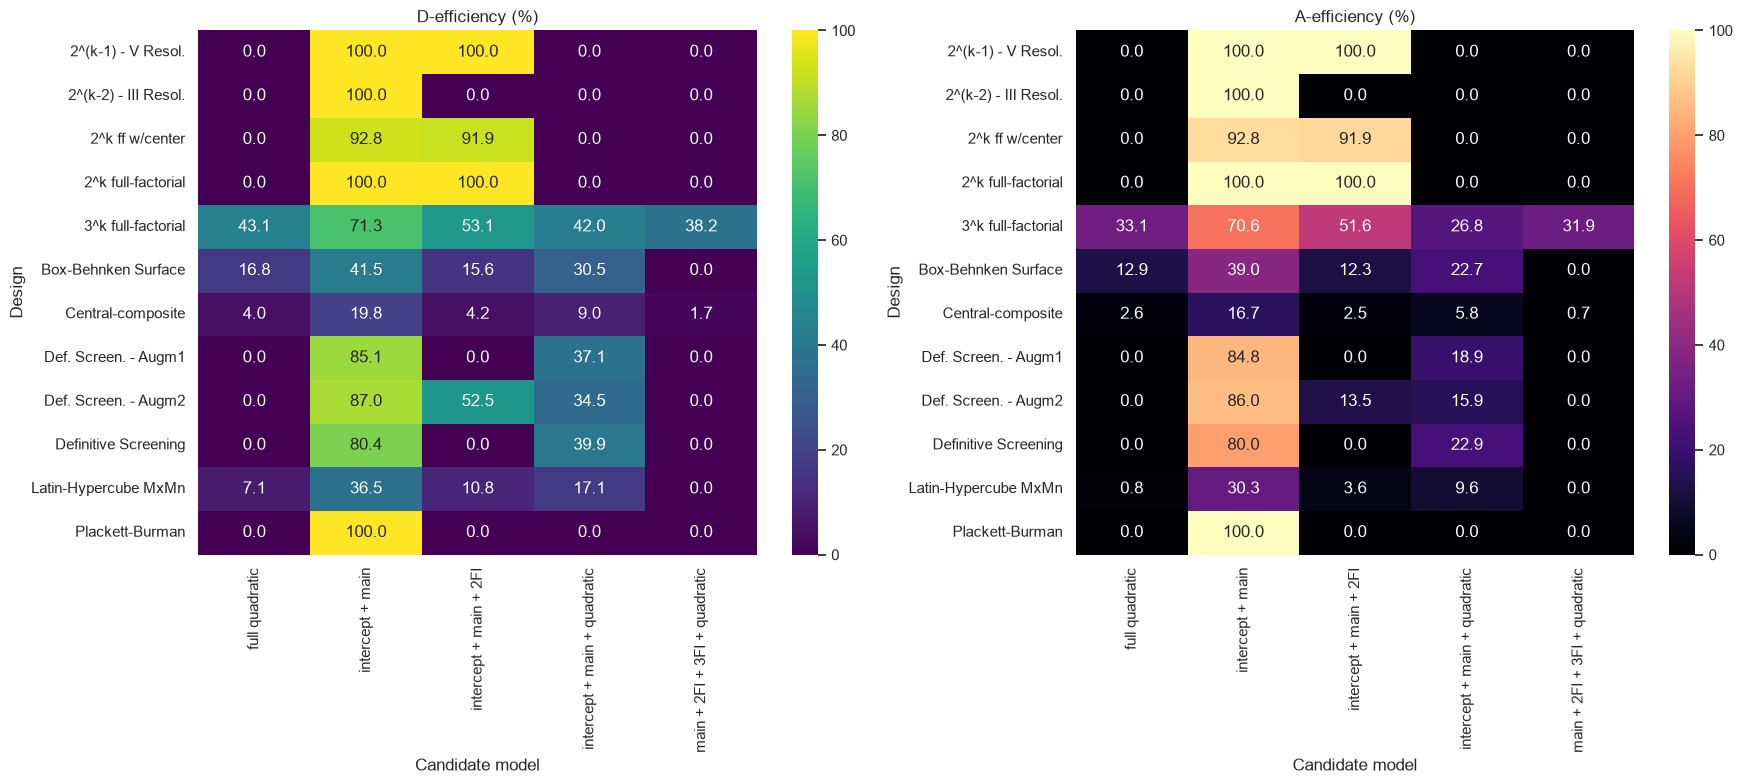

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(d_efficiency_table, annot=True, fmt=".1f", cmap="viridis", vmin=0, vmax=100, ax=axes[0])
sns.heatmap(a_efficiency_table, annot=True, fmt=".1f", cmap="magma", vmin=0, vmax=100, ax=axes[1])
axes[0].set_title("D-efficiency (%)")
axes[1].set_title("A-efficiency (%)")
for ax in axes:
    ax.set(xlabel="Candidate model", ylabel="Design")
plt.tight_layout()
plt.show()
plt.close(fig)

## Prediction-variance profile

All factors except `X1` are held at the center. The model contains the intercept, main effects, and pure quadratics. Curves are normalized by their minimum so their shapes can be compared.

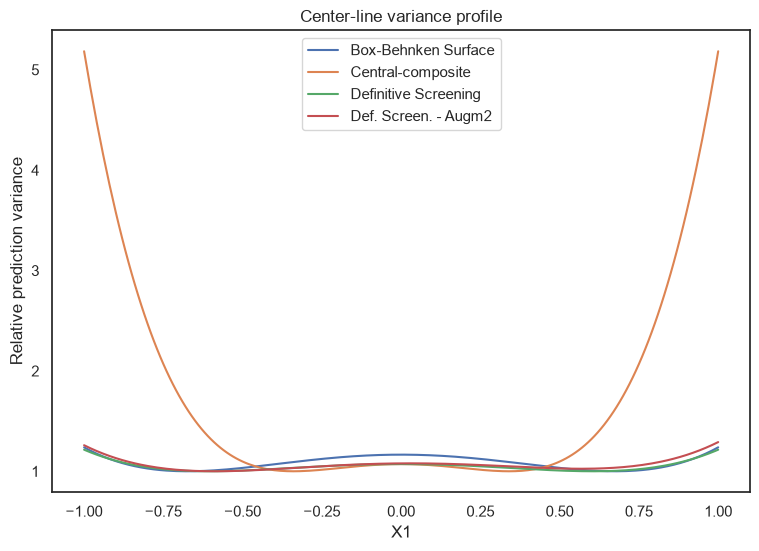

In [8]:
grid = np.zeros((201, k))
grid[:, 0] = np.linspace(-1, 1, len(grid))
variance_effects = ["intercept", "main", "quadratic"]

fig, ax = plt.subplots(figsize=(9, 6))
for name in ["Box-Behnken Surface", "Central-composite", "Definitive Screening", "Def. Screen. - Augm2"]:
    variance = prediction_variance(does[name], grid, variance_effects)
    ax.plot(grid[:, 0], variance / variance.min(), label=name)
ax.set(xlabel="X1", ylabel="Relative prediction variance", title="Center-line variance profile")
ax.legend()
plt.show()
plt.close(fig)

## Exact aliases for the regular fractions

Correlation maps work for general numerical designs. For regular two-level fractions, pydoe additionally provides symbolic alias chains.

In [9]:
for name, design in [("Resolution V", AfrV), ("Resolution III", AfrIII)]:
    alias_map, alias_cost = pydoe.fracfact_aliasing(design)
    print(f"{name}: first ten alias chains")
    for chain in alias_map[:10]:
        print(" ", chain)
    print("Alias-cost vector:", alias_cost, "\n")

Resolution V: first ten alias chains
  a = bcde
  b = acde
  c = abde
  d = abce
  e = abcd
  ab = cde
  ac = bde
  ad = bce
  ae = bcd
  bc = ade
Alias-cost vector: [ 0.  0.  0.  0. 10.  0.  5.  0.  0.  0.  0.  0.  0.  0.  0.] 

Resolution III: first ten alias chains
  a = bd = ce = abcde
  b = ad = cde = abce
  c = ae = bde = abcd
  d = ab = bce = acde
  e = ac = bcd = abde
  bc = de = abe = acd
  be = cd = abc = ade
  abd = ace = bcde
Alias-cost vector: [ 0.  6.  3.  4. 12.  3.  4.  4.  6.  0.  1.  2.  0.  0.  0.] 

